In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import chi2_contingency
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

from google.colab import drive

drive.mount('/content/drive')
train_file_path = '/content/drive/MyDrive/ml-project/part2/train_dataset.csv'

train_df = pd.read_csv(train_file_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [81]:
# Run this first in Colab
# !pip install cuml-cu11 --extra-index-url=https://pypi.nvidia.com
# !pip install optuna

In [82]:
train_df.head()

,age,height(cm),weight(kg),waist(cm),eyesight(left),eyesight(right),hearing(left),hearing(right),systolic,relaxation,fasting blood sugar,Cholesterol,triglyceride,HDL,LDL,hemoglobin,Urine protein,serum creatinine,AST,ALT,Gtp,dental caries,smoking
0,35,170,85,97.000,0.900,0.900,1,1,118,78,97,239,153,70,142,19.800,1,1.000,61,115,125,1,1
1,20,175,110,110.000,0.700,0.900,1,1,119,79,88,211,128,71,114,15.900,1,1.100,19,25,30,1,0
2,45,155,65,86.000,0.900,0.900,1,1,110,80,80,193,120,57,112,13.700,3,0.600,1090,1400,276,0,0
3,45,165,80,94.000,0.800,0.700,1,1,158,88,249,210,366,46,91,16.900,1,0.900,32,36,36,0,0
4,20,165,60,81.000,1.500,0.100,1,1,109,64,100,179,200,47,92,14.900,1,1.200,26,28,15,0,0


In [83]:
print(f"Training set shape: {train_df.shape}")
print(f"\nTraining set size: {train_df.shape[0]:,} rows × {train_df.shape[1]} columns")

Training set shape: (38984, 23)

Training set size: 38,984 rows × 23 columns


# 3. Statistical Summary

In [84]:
print("statistical summary : \n\n")
display(train_df.describe().T)

print("Additional summary : \n")
stats_df = pd.DataFrame({
    'Missing_Values': train_df.isnull().sum(),
    'Missing_Percentage': (train_df.isnull().sum() / len(train_df) * 100),
    'Unique_Values': train_df.nunique(),
    'Data_Type': train_df.dtypes
})
display(stats_df)

statistical summary : 




,count,mean,std,min,25%,50%,75%,max
age,38984.000,44.128,12.064,20.000,40.000,40.000,55.000,85.000
height(cm),38984.000,164.689,9.188,130.000,160.000,165.000,170.000,190.000
weight(kg),38984.000,65.939,12.897,30.000,55.000,65.000,75.000,135.000
waist(cm),38984.000,82.062,9.327,51.000,76.000,82.000,88.000,129.000
eyesight(left),38984.000,1.015,0.499,0.100,0.800,1.000,1.200,9.900
eyesight(right),38984.000,1.009,0.494,0.100,0.800,1.000,1.200,9.900
hearing(left),38984.000,1.025,0.157,1.000,1.000,1.000,1.000,2.000
hearing(right),38984.000,1.026,0.160,1.000,1.000,1.000,1.000,2.000
systolic,38984.000,121.476,13.644,71.000,112.000,120.000,130.000,233.000
relaxation,38984.000,75.994,9.659,40.000,70.000,76.000,82.000,146.000


Additional summary : 



,Missing_Values,Missing_Percentage,Unique_Values,Data_Type
age,0,0.000,14,int64
height(cm),0,0.000,13,int64
weight(kg),0,0.000,22,int64
waist(cm),0,0.000,545,float64
eyesight(left),0,0.000,19,float64
eyesight(right),0,0.000,17,float64
hearing(left),0,0.000,2,int64
hearing(right),0,0.000,2,int64
systolic,0,0.000,125,int64
relaxation,0,0.000,94,int64


# 4. Target Variable Analysis


--- Smoking Status Distribution ---
Non-Smokers (0): 24,666 (63.27%)
Smokers (1): 14,318 (36.73%)

Class Imbalance Ratio: 1:1.72


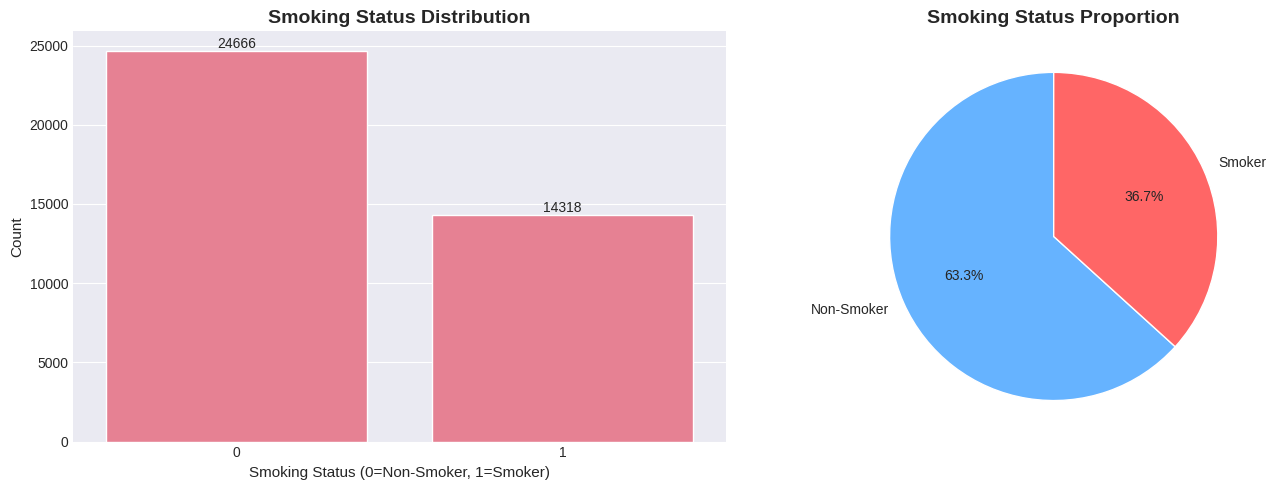

In [85]:
# Target distribution
target_counts = train_df['smoking'].value_counts()
target_pct = train_df['smoking'].value_counts(normalize=True) * 100

print("\n--- Smoking Status Distribution ---")
print(f"Non-Smokers (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Smokers (1): {target_counts[1]:,} ({target_pct[1]:.2f}%)")
print(f"\nClass Imbalance Ratio: 1:{target_counts[0]/target_counts[1]:.2f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count plot
sns.countplot(data=train_df, x='smoking', ax=axes[0])
axes[0].set_title('Smoking Status Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Smoking Status (0=Non-Smoker, 1=Smoker)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d')

# Pie chart
axes[1].pie(target_counts, labels=['Non-Smoker', 'Smoker'], autopct='%1.1f%%',
            startangle=90, colors=['#66b3ff', '#ff6666'])
axes[1].set_title('Smoking Status Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Correlation Analysis


Top 10 Features Correlated with Smoking Status
hemoglobin            0.401
height(cm)            0.394
weight(kg)            0.299
triglyceride          0.251
Gtp                   0.240
waist(cm)             0.223
serum creatinine      0.212
dental caries         0.108
relaxation            0.104
fasting blood sugar   0.100
Name: smoking, dtype: float64

Bottom 10 Features Correlated with Smoking Status
eyesight(right)    0.065
AST                0.063
eyesight(left)     0.059
Urine protein      0.014
hearing(right)    -0.019
hearing(left)     -0.022
Cholesterol       -0.027
LDL               -0.042
age               -0.166
HDL               -0.180
Name: smoking, dtype: float64


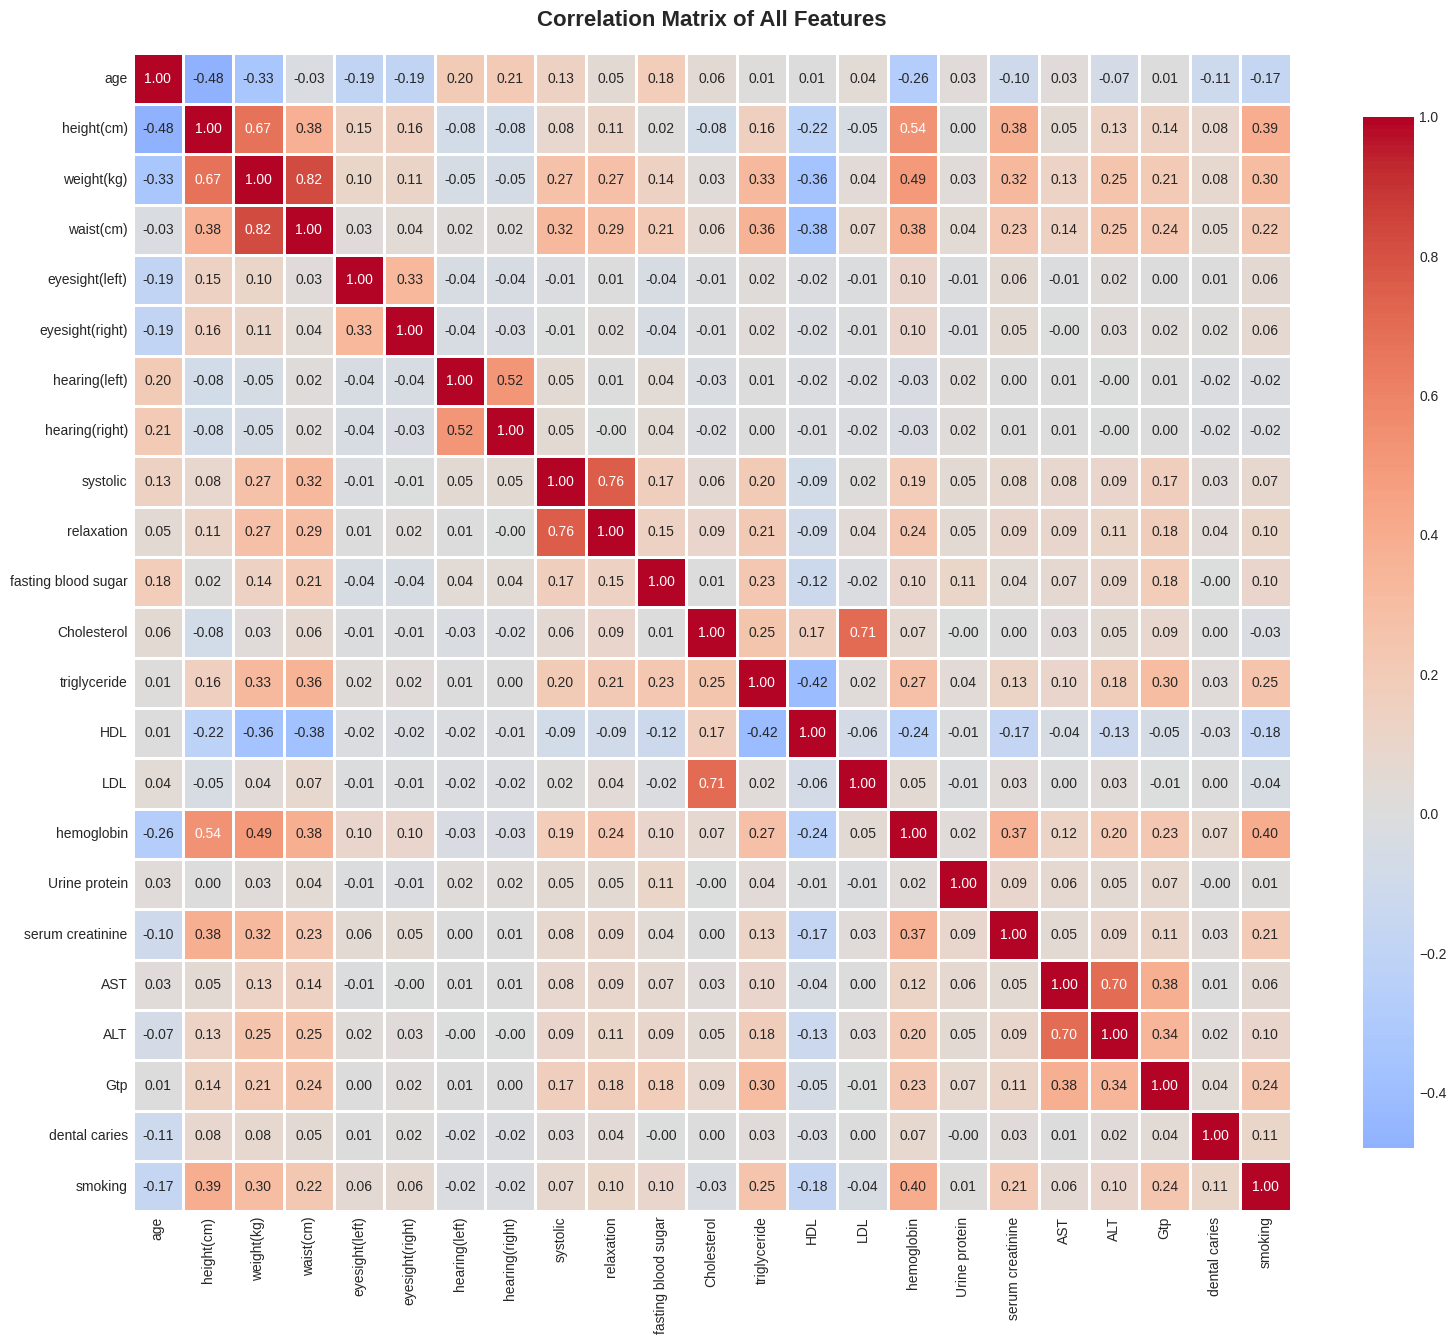

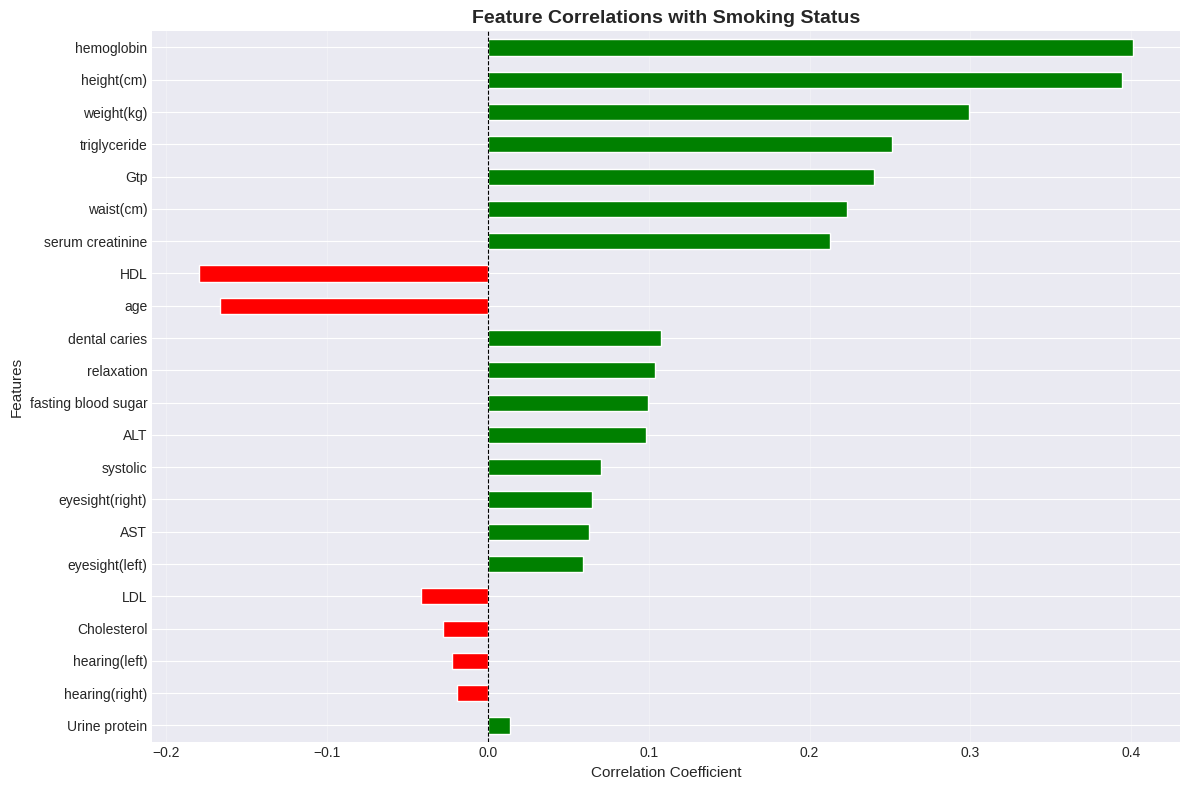


Highly Correlated Feature Pairs (|correlation| > 0.7)
weight(kg) <-> waist(cm): 0.825
systolic <-> relaxation: 0.759
Cholesterol <-> LDL: 0.707


In [86]:
# Define numerical columns
numerical_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
if 'smoking' in numerical_cols:
    numerical_cols.remove('smoking')

# Calculate correlation matrix
corr_matrix = train_df[numerical_cols + ['smoking']].corr()

# Top correlations with target variable
target_corr = corr_matrix['smoking'].drop('smoking').sort_values(ascending=False)
print("\nTop 10 Features Correlated with Smoking Status")
print(target_corr.head(10))

print("\nBottom 10 Features Correlated with Smoking Status")
print(target_corr.tail(10))

# Correlation heatmap
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Feature correlation with target (bar plot)
plt.figure(figsize=(12, 8))
target_corr_abs = target_corr.abs().sort_values(ascending=True)
colors = ['red' if x < 0 else 'green' for x in target_corr[target_corr_abs.index]]
target_corr[target_corr_abs.index].plot(kind='barh', color=colors)
plt.title('Feature Correlations with Smoking Status', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Coefficient', fontsize=11)
plt.ylabel('Features', fontsize=11)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Highly correlated feature pairs (excluding target)
print("\nHighly Correlated Feature Pairs (|correlation| > 0.7)")
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7 and corr_matrix.columns[i] != 'smoking' and corr_matrix.columns[j] != 'smoking':
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    for feat1, feat2, corr_val in high_corr_pairs:
        print(f"{feat1} <-> {feat2}: {corr_val:.3f}")
else:
    print("No highly correlated feature pairs found (excluding target)")

# 6. Distribution Plots for Numerical Features

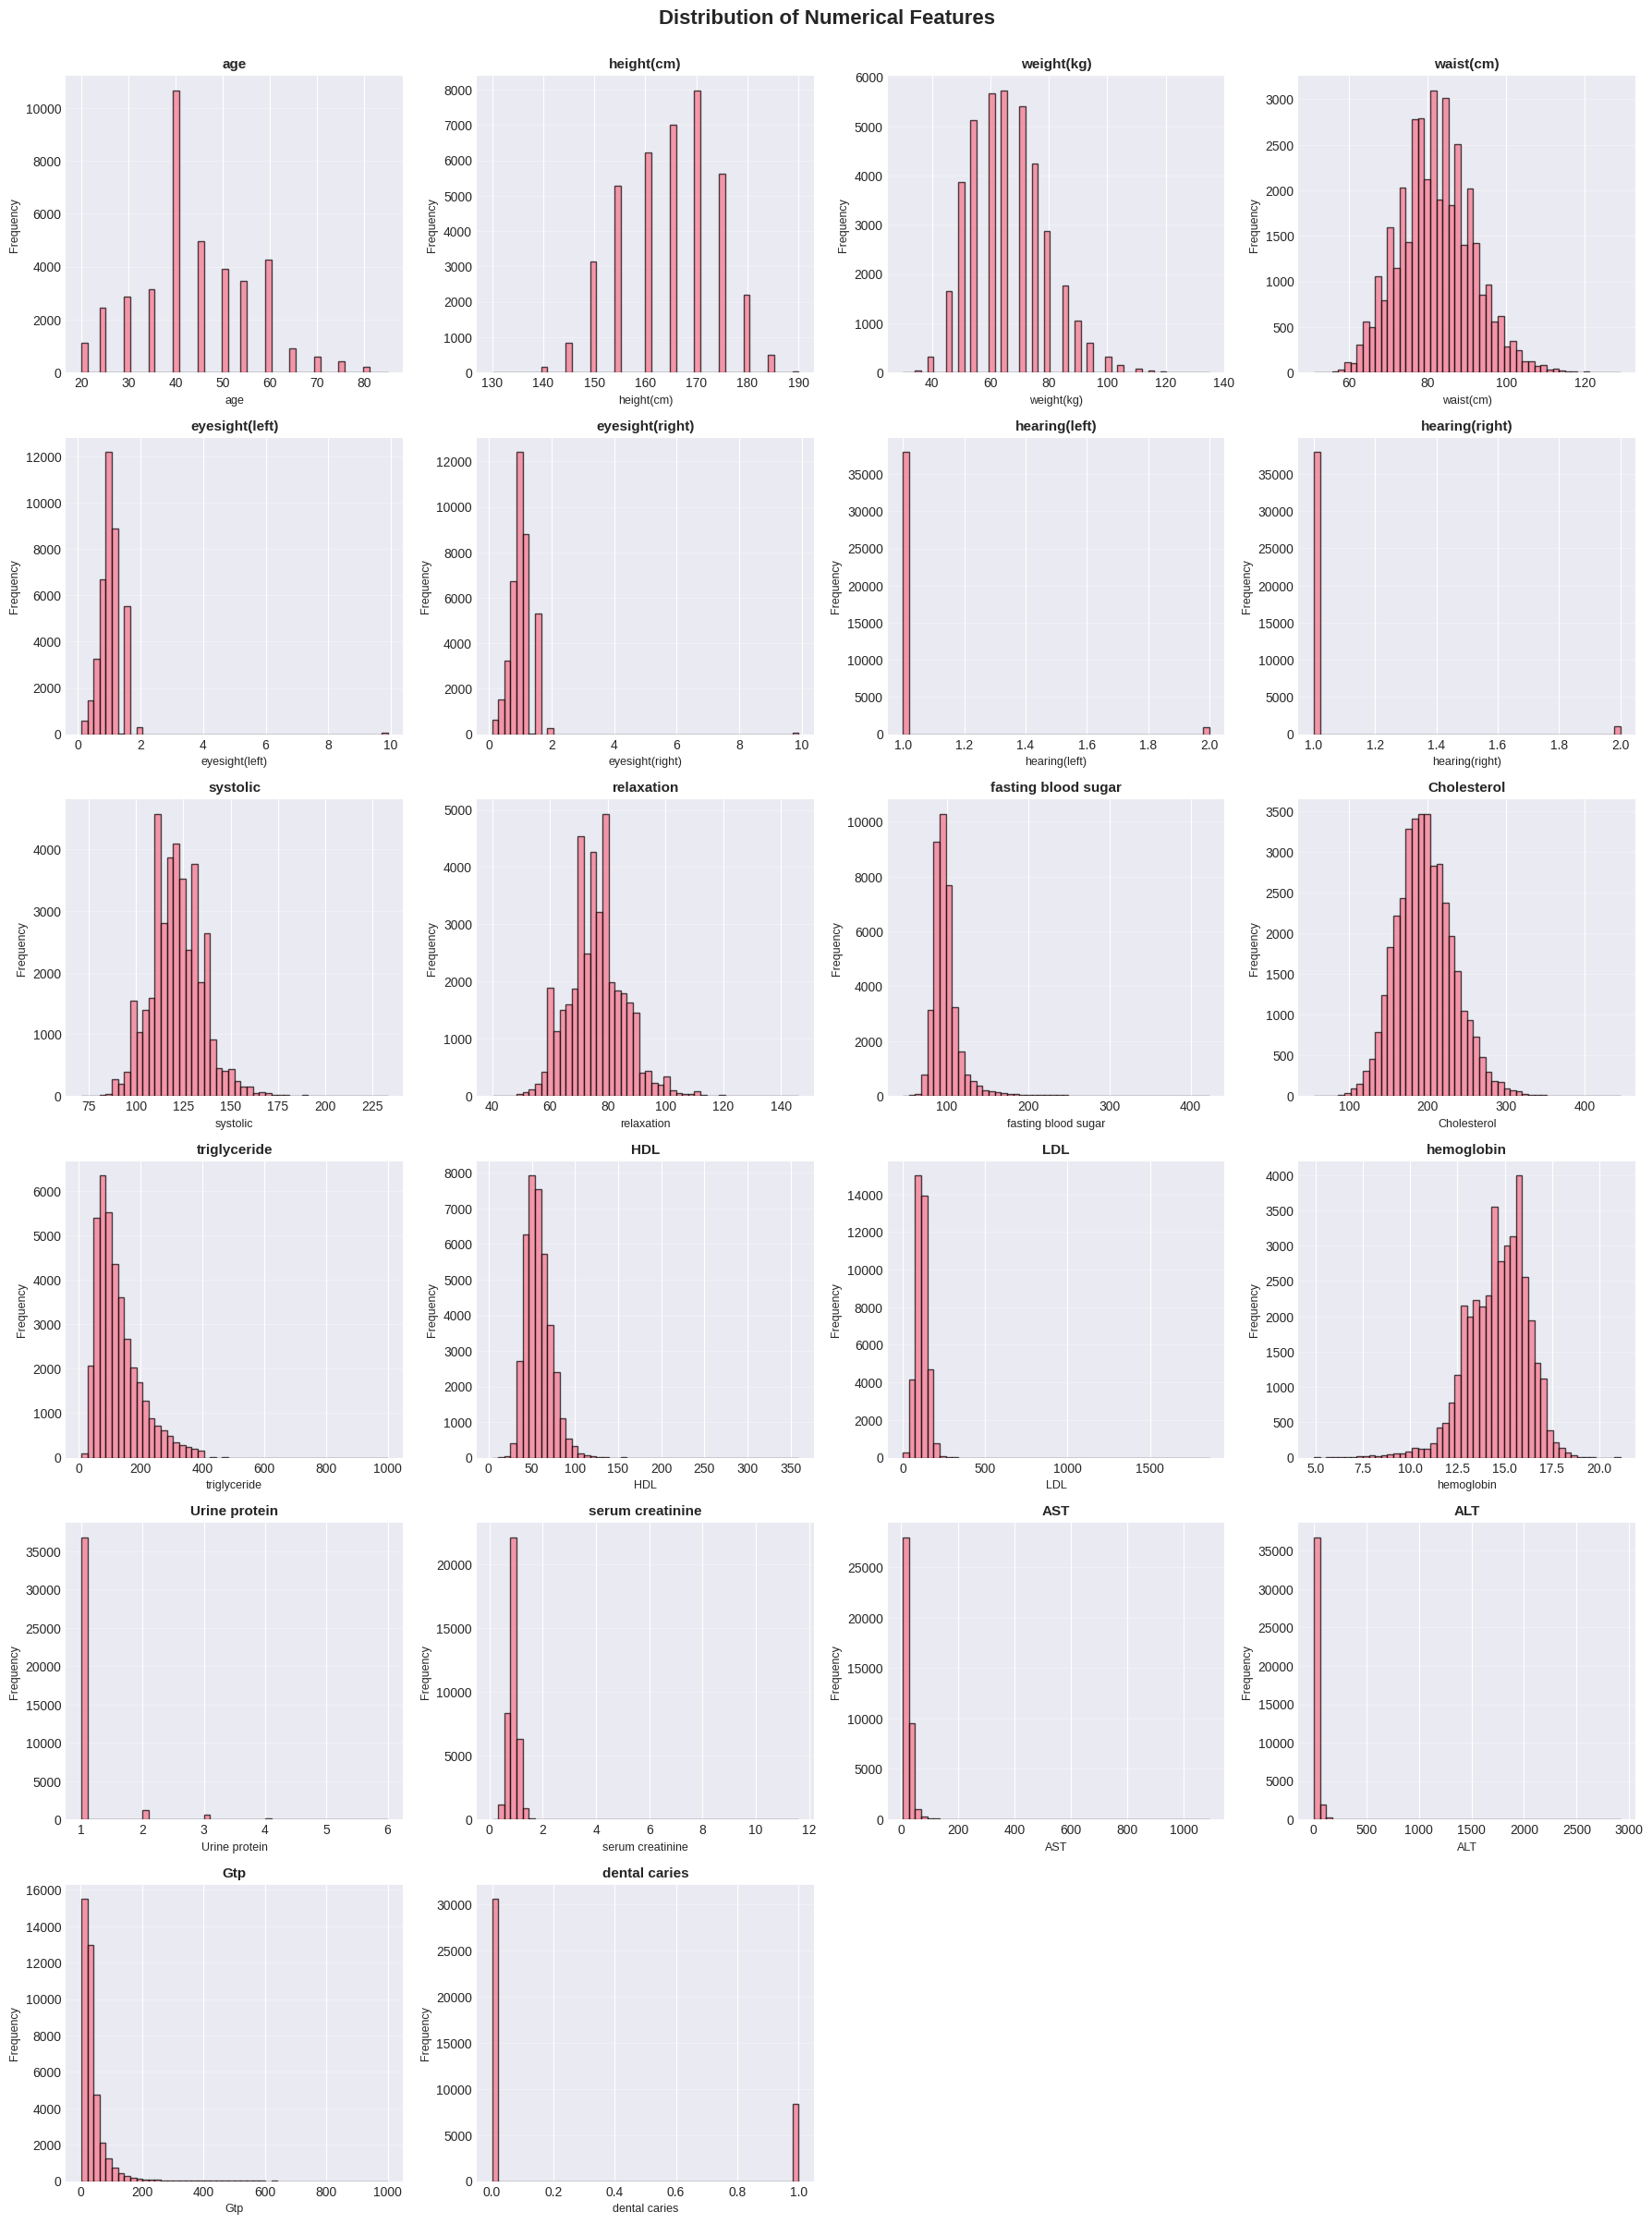

In [87]:
# Histograms for all numerical features
n_cols = 4
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(train_df[col], bins=50, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=9)
    axes[idx].set_ylabel('Frequency', fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

# 7. Boxplots for Outlier Detection

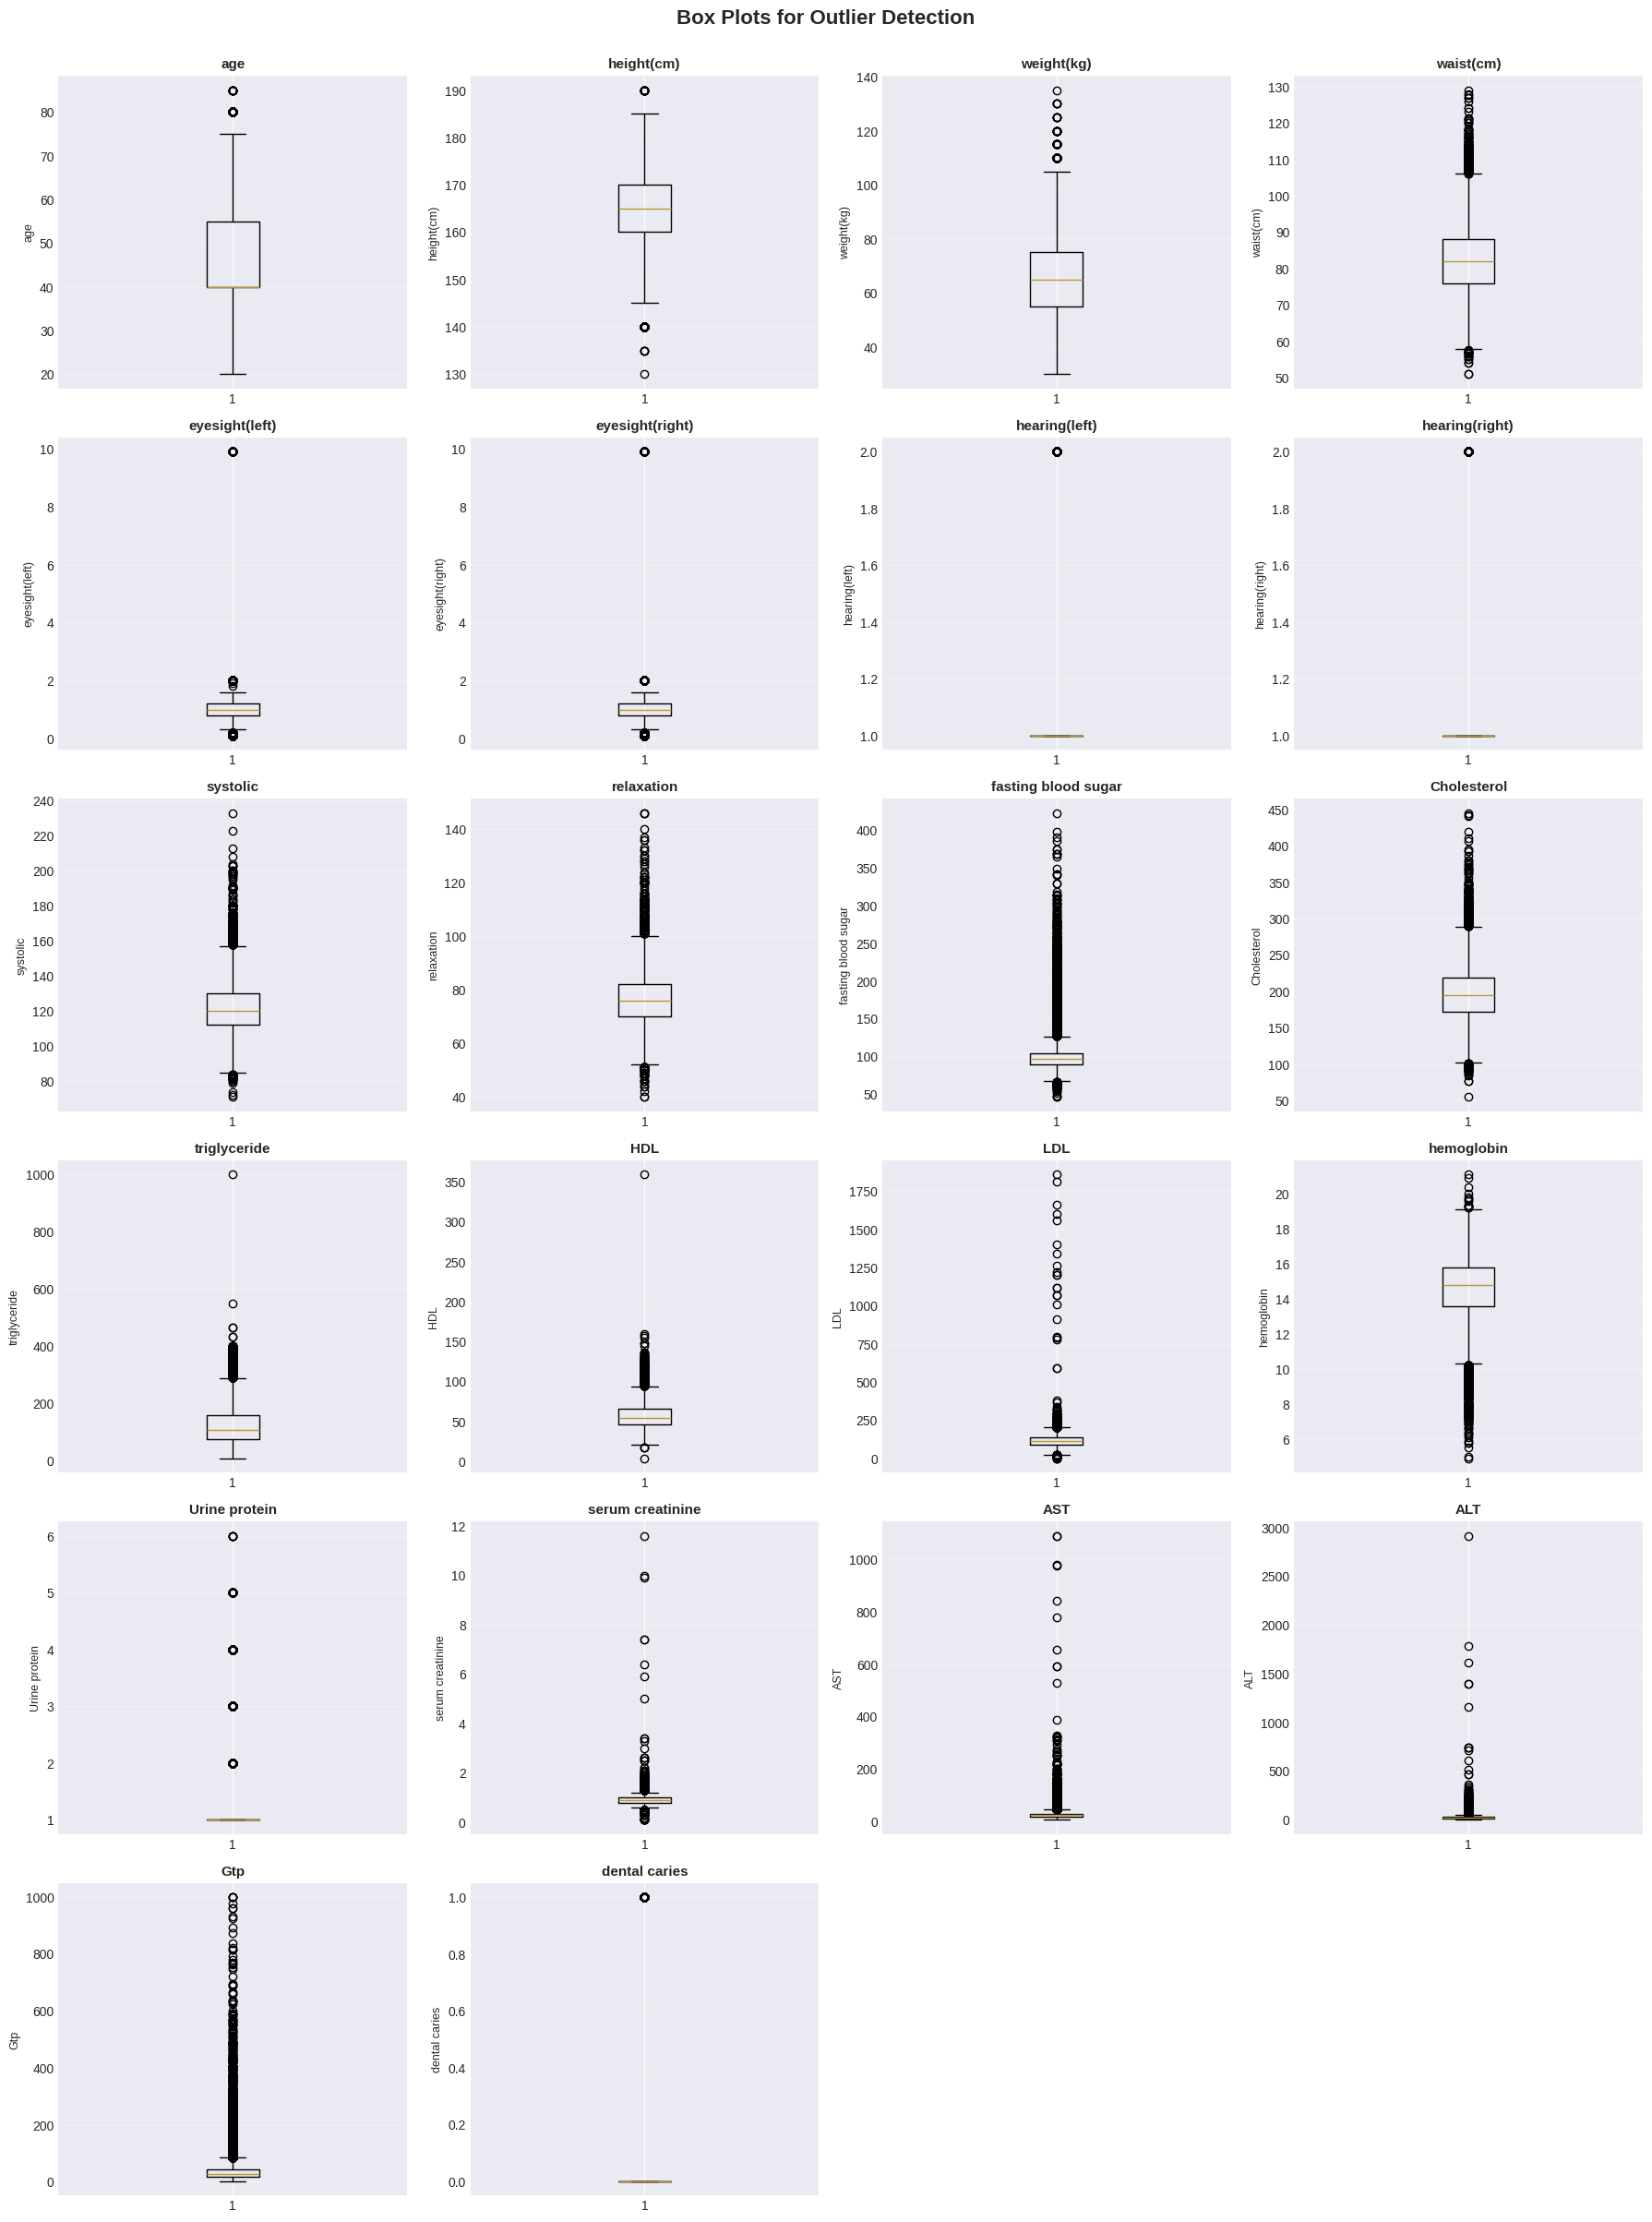


Outlier Statistics (IQR Method)


,Feature,Outlier_Count,Outlier_Percentage
21,dental caries,8359,21.442
20,Gtp,3375,8.657
19,ALT,2642,6.777
10,fasting blood sugar,2316,5.941
17,serum creatinine,2189,5.615
16,Urine protein,2148,5.510
18,AST,2111,5.415
12,triglyceride,1607,4.122
7,hearing(right),1021,2.619
6,hearing(left),989,2.537


In [88]:
# Box plots for all numerical features
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols):
    axes[idx].boxplot(train_df[col].dropna(), vert=True)
    axes[idx].set_title(f'{col}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(col, fontsize=9)
    axes[idx].grid(axis='y', alpha=0.3)

# Hide unused subplots
for idx in range(len(numerical_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Box Plots for Outlier Detection', fontsize=16, fontweight='bold', y=1.001)
plt.tight_layout()
plt.show()

# Outlier statistics using IQR method
print("\nOutlier Statistics (IQR Method)")
outlier_stats = []
for col in numerical_cols:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = train_df[(train_df[col] < lower_bound) | (train_df[col] > upper_bound)][col]
    outlier_stats.append({
        'Feature': col,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': (len(outliers) / len(train_df)) * 100
    })

outlier_df = pd.DataFrame(outlier_stats).sort_values('Outlier_Count', ascending=False)
display(outlier_df)

# 13. BMI Calculations and Analysis


BMI Statistics

            count   mean   std    min    25%    50%    75%    max
smoking                                                          
0       24666.000 23.899 3.454 14.269 21.484 23.437 25.952 42.449
1       14318.000 24.665 3.535 14.692 22.491 24.221 26.297 41.667

BMI Category Distribution by Smoking Status (%)
smoking           0      1
BMI_Category              
Normal       64.530 55.043
Obese         4.727  6.656
Overweight   27.317 35.480
Underweight   3.426  2.822


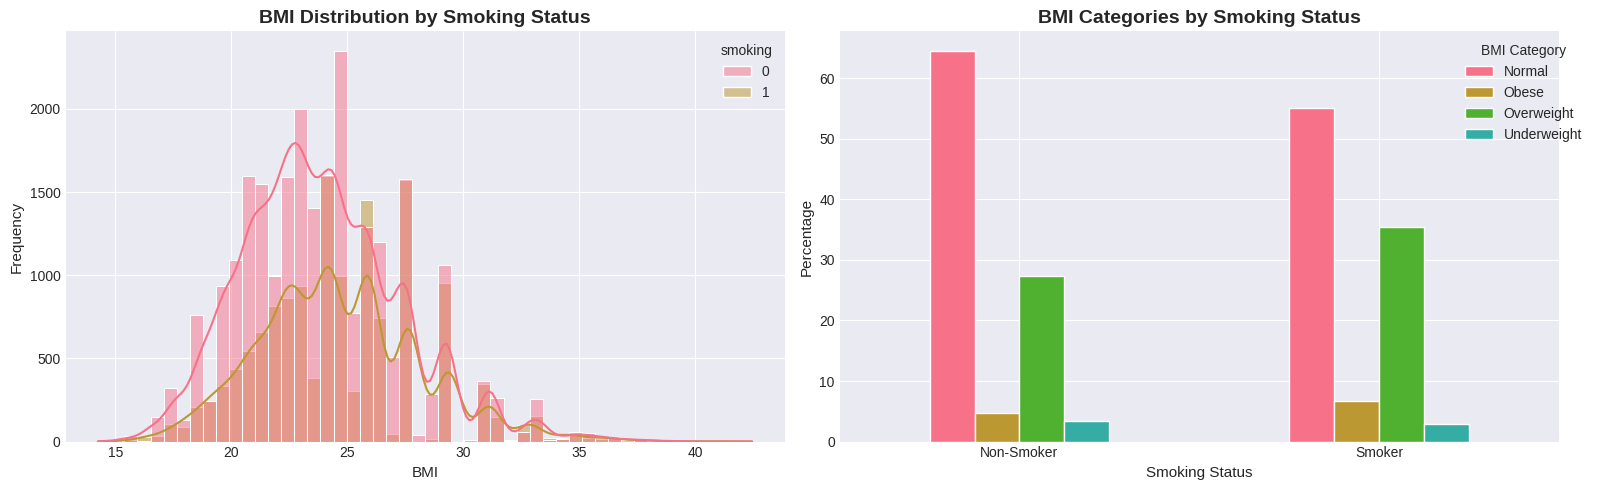

In [89]:
# Calculate BMI
train_df['BMI'] = train_df['weight(kg)'] / ((train_df['height(cm)'] / 100) ** 2)

print("\nBMI Statistics\n")
print(train_df.groupby('smoking')['BMI'].describe())

# BMI categories
def categorize_bmi(bmi):
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

train_df['BMI_Category'] = train_df['BMI'].apply(categorize_bmi)

# BMI category distribution by smoking status
bmi_smoking = pd.crosstab(train_df['BMI_Category'], train_df['smoking'], normalize='columns') * 100

print("\nBMI Category Distribution by Smoking Status (%)")
print(bmi_smoking)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BMI distribution
sns.histplot(data=train_df, x='BMI', hue='smoking', kde=True, bins=50, ax=axes[0])
axes[0].set_title('BMI Distribution by Smoking Status', fontsize=14, fontweight='bold')
axes[0].set_xlabel('BMI', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)

# BMI category by smoking
bmi_smoking.T.plot(kind='bar', ax=axes[1], rot=0)
axes[1].set_title('BMI Categories by Smoking Status', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Smoking Status', fontsize=11)
axes[1].set_ylabel('Percentage', fontsize=11)
axes[1].set_xticklabels(['Non-Smoker', 'Smoker'])
axes[1].legend(title='BMI Category', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

# Smokers vs Non-Smokers

EXPLORATORY DATA ANALYSIS: SMOKERS VS NON-SMOKERS

Dataset shape: (38984, 25)
Smokers: 14318 (36.7%)
Non-smokers: 24666 (63.3%)



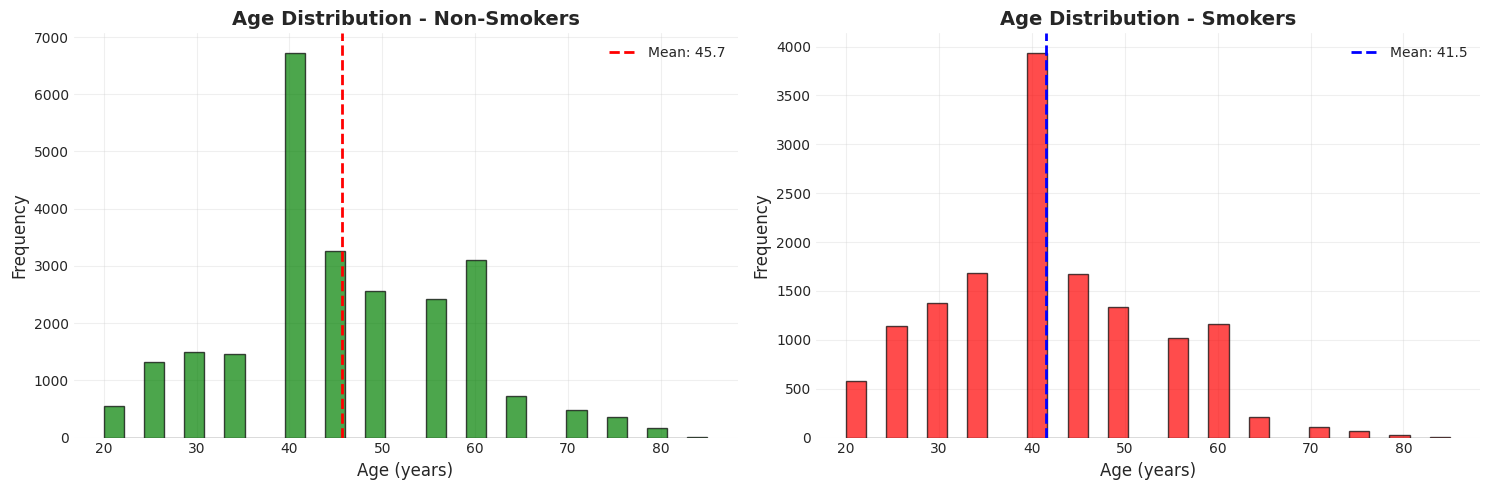

AGE STATISTICS:
  Non-smokers: Mean=45.7, Median=45.0
  Smokers:     Mean=41.5, Median=40.0



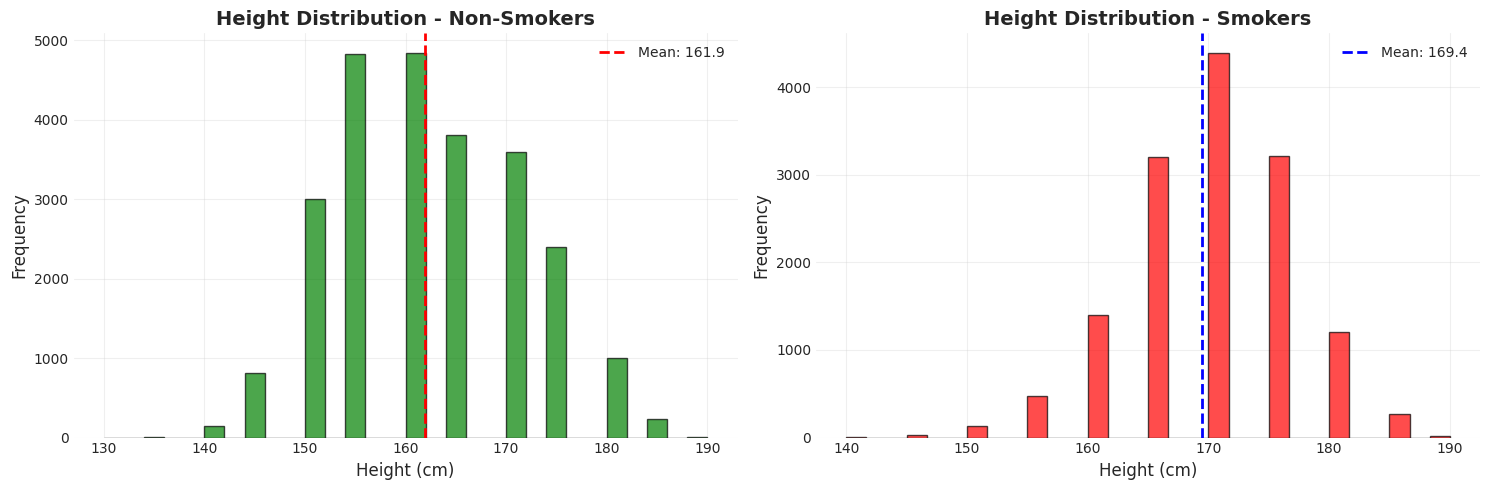

HEIGHT STATISTICS:
  Non-smokers: Mean=161.9 cm
  Smokers:     Mean=169.4 cm



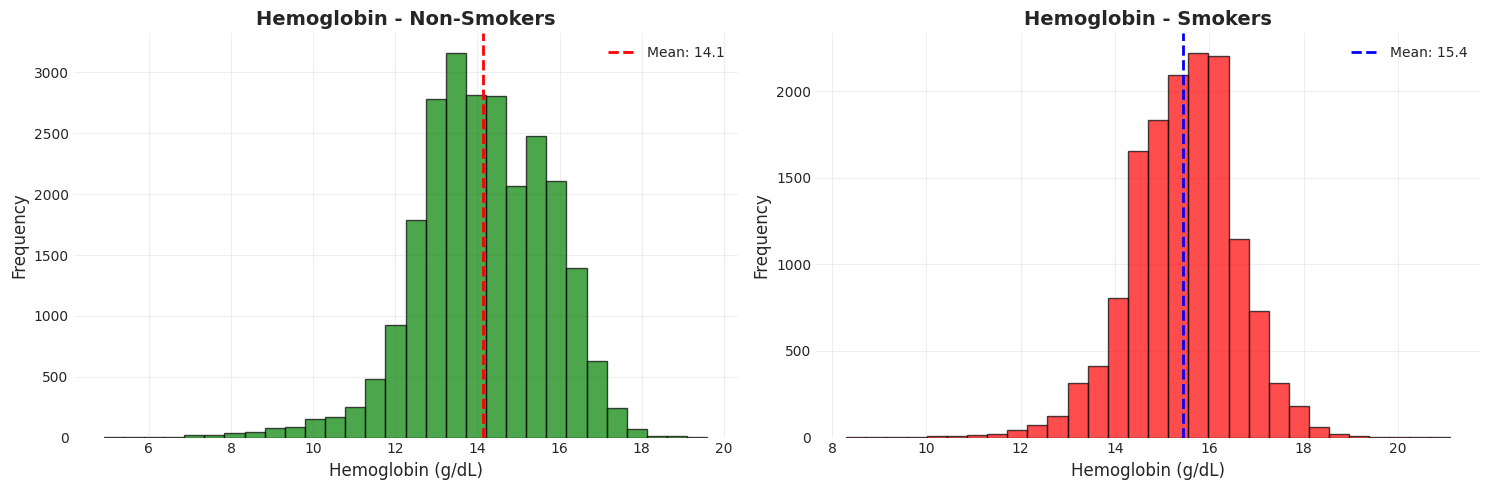

HEMOGLOBIN STATISTICS:
  Non-smokers: Mean=14.15 g/dL
  Smokers:     Mean=15.45 g/dL
  Difference:  1.30 g/dL



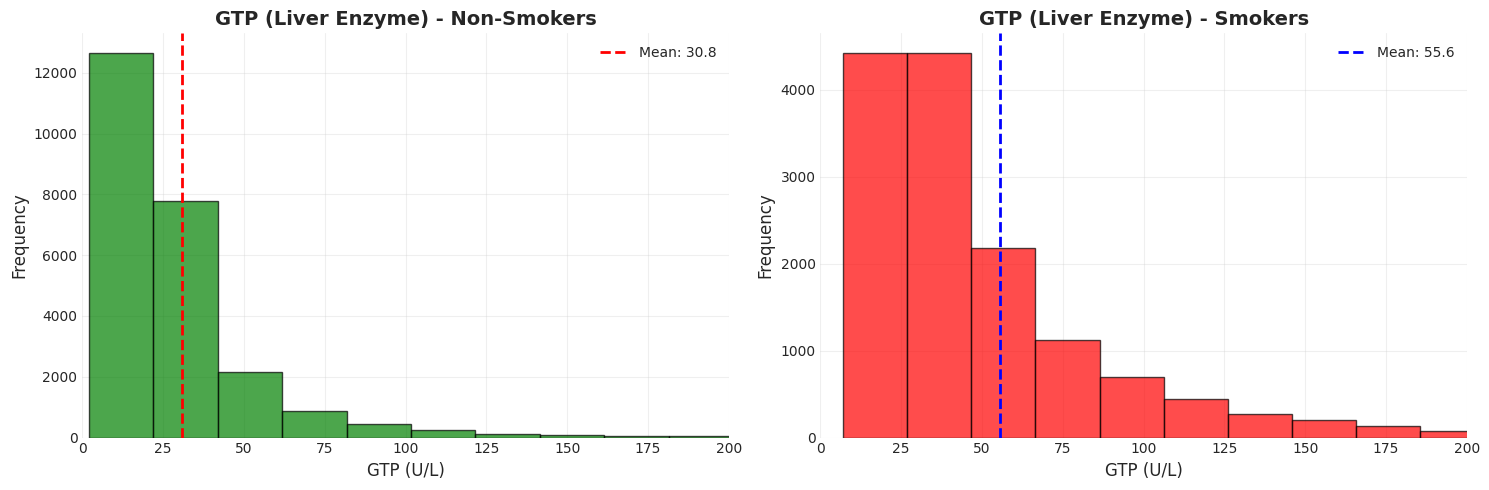

GTP STATISTICS:
  Non-smokers: Mean=30.8 U/L
  Smokers:     Mean=55.6 U/L



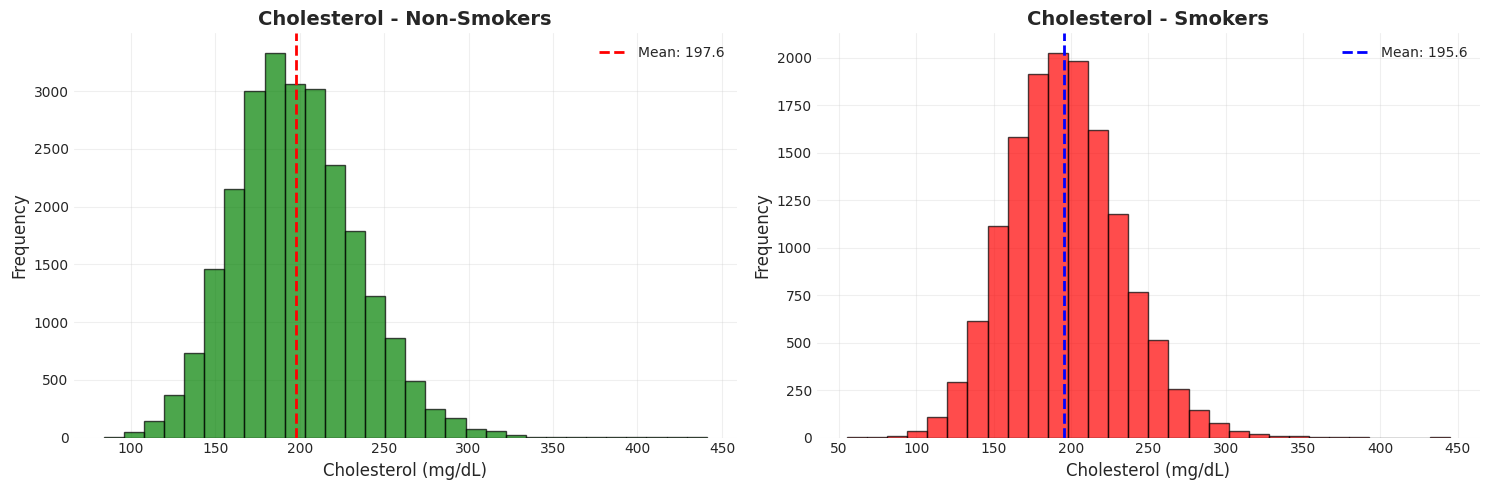

CHOLESTEROL STATISTICS:
  Non-smokers: Mean=197.6 mg/dL
  Smokers:     Mean=195.6 mg/dL



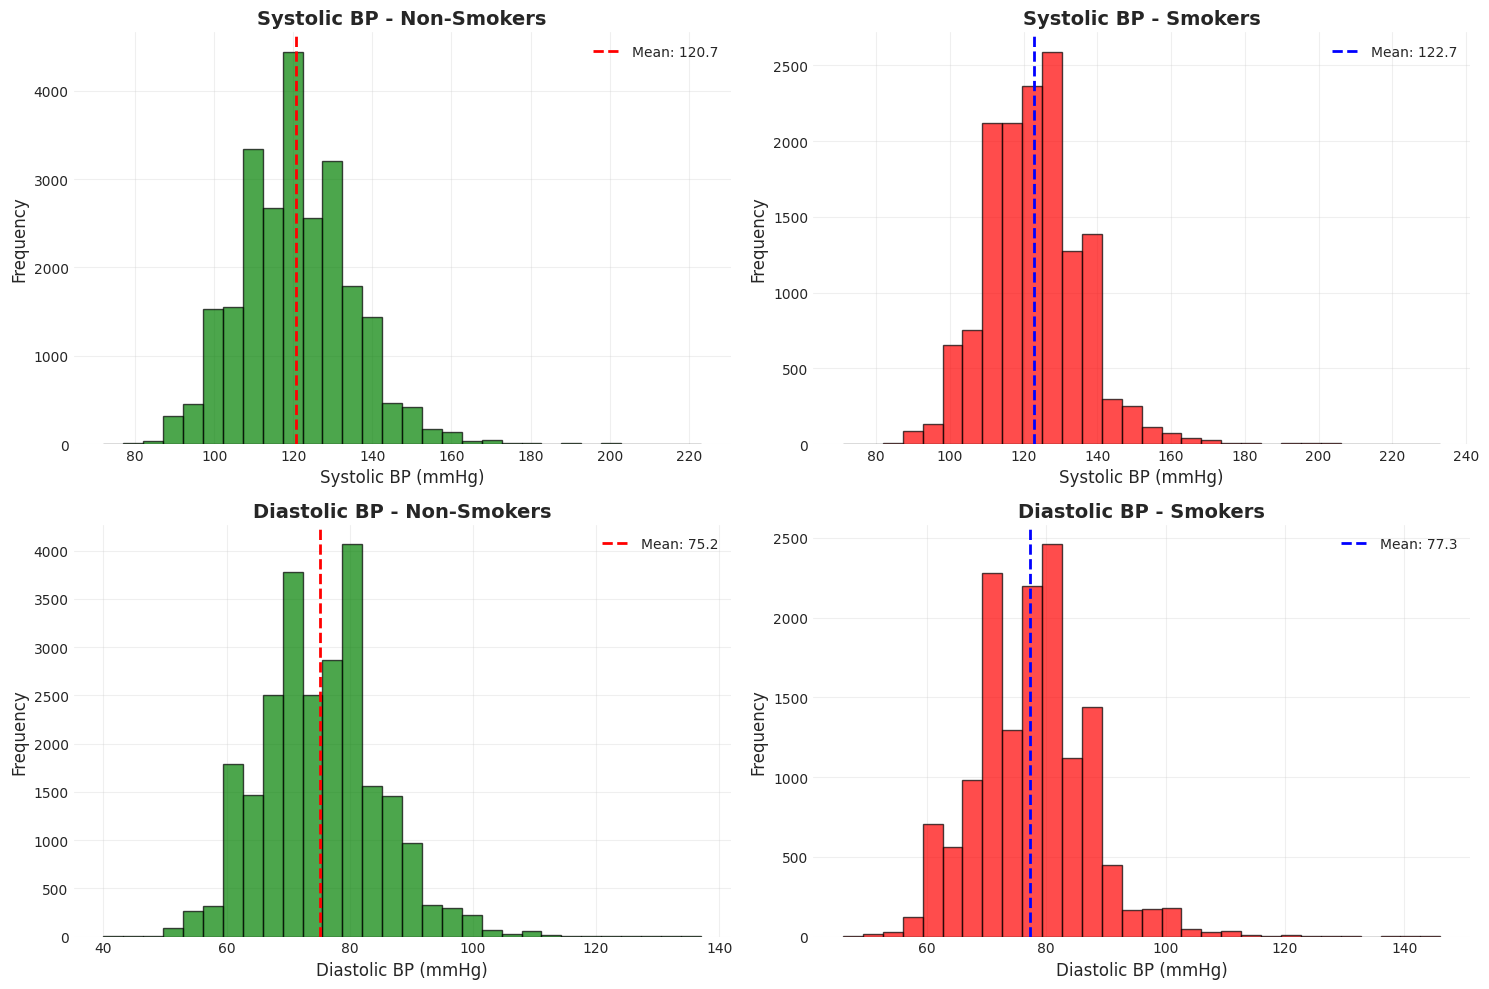

BLOOD PRESSURE STATISTICS:
  Systolic - Non-smokers: 120.7 mmHg
  Systolic - Smokers:     122.7 mmHg
  Diastolic - Non-smokers: 75.2 mmHg
  Diastolic - Smokers:     77.3 mmHg



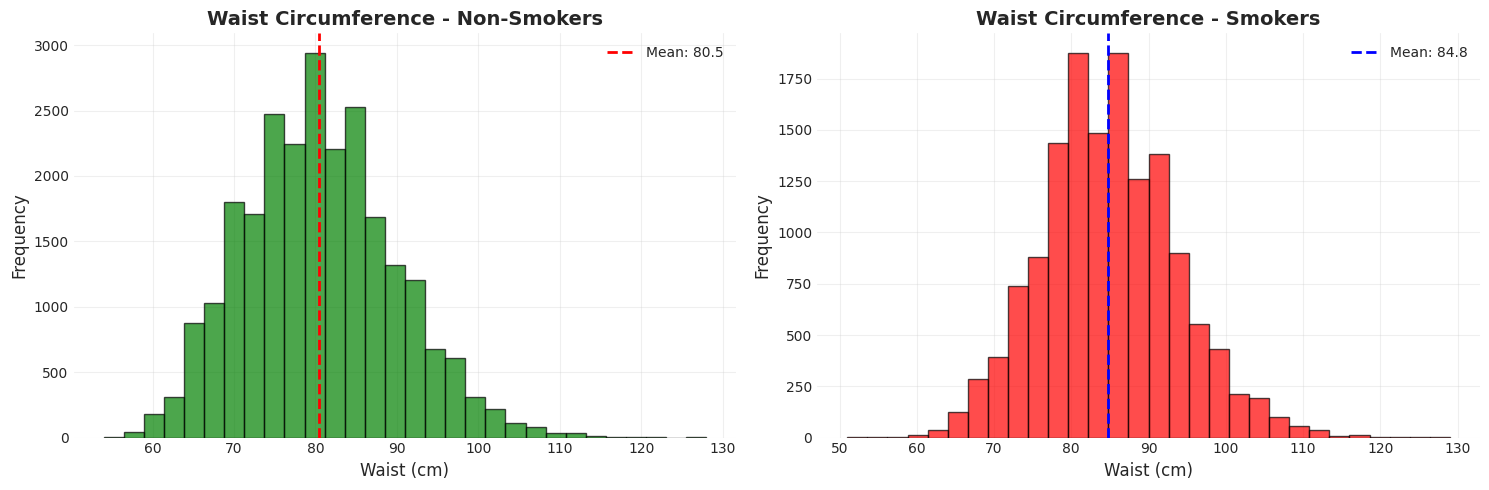

WAIST STATISTICS:
  Non-smokers: Mean=80.5 cm
  Smokers:     Mean=84.8 cm



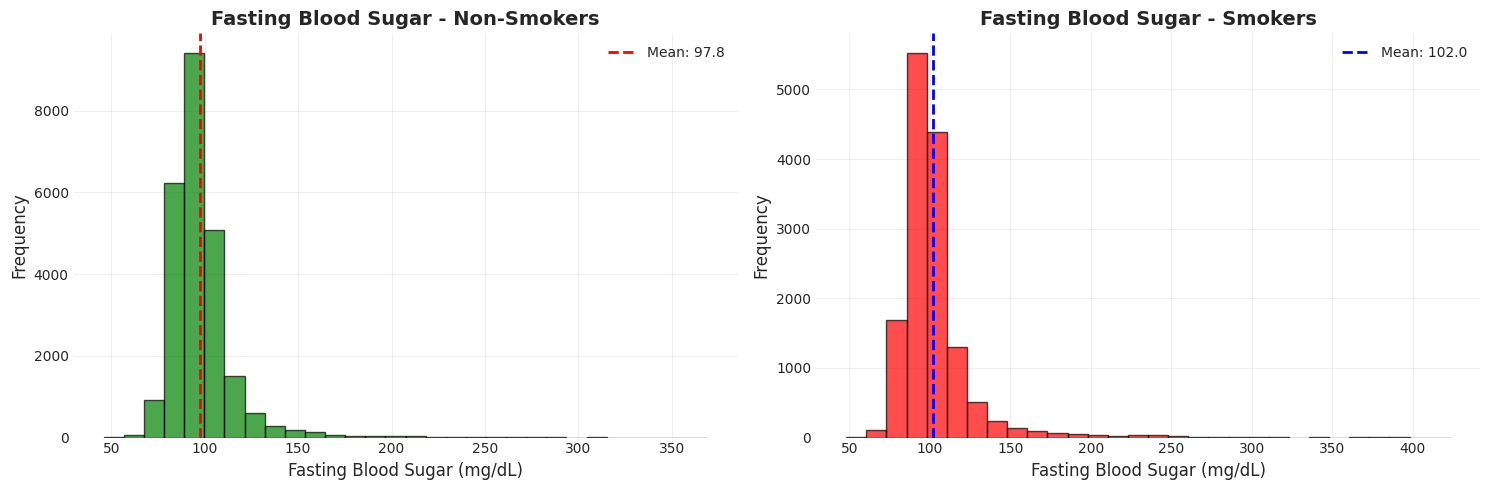

FASTING BLOOD SUGAR STATISTICS:
  Non-smokers: Mean=97.8 mg/dL
  Smokers:     Mean=102.0 mg/dL



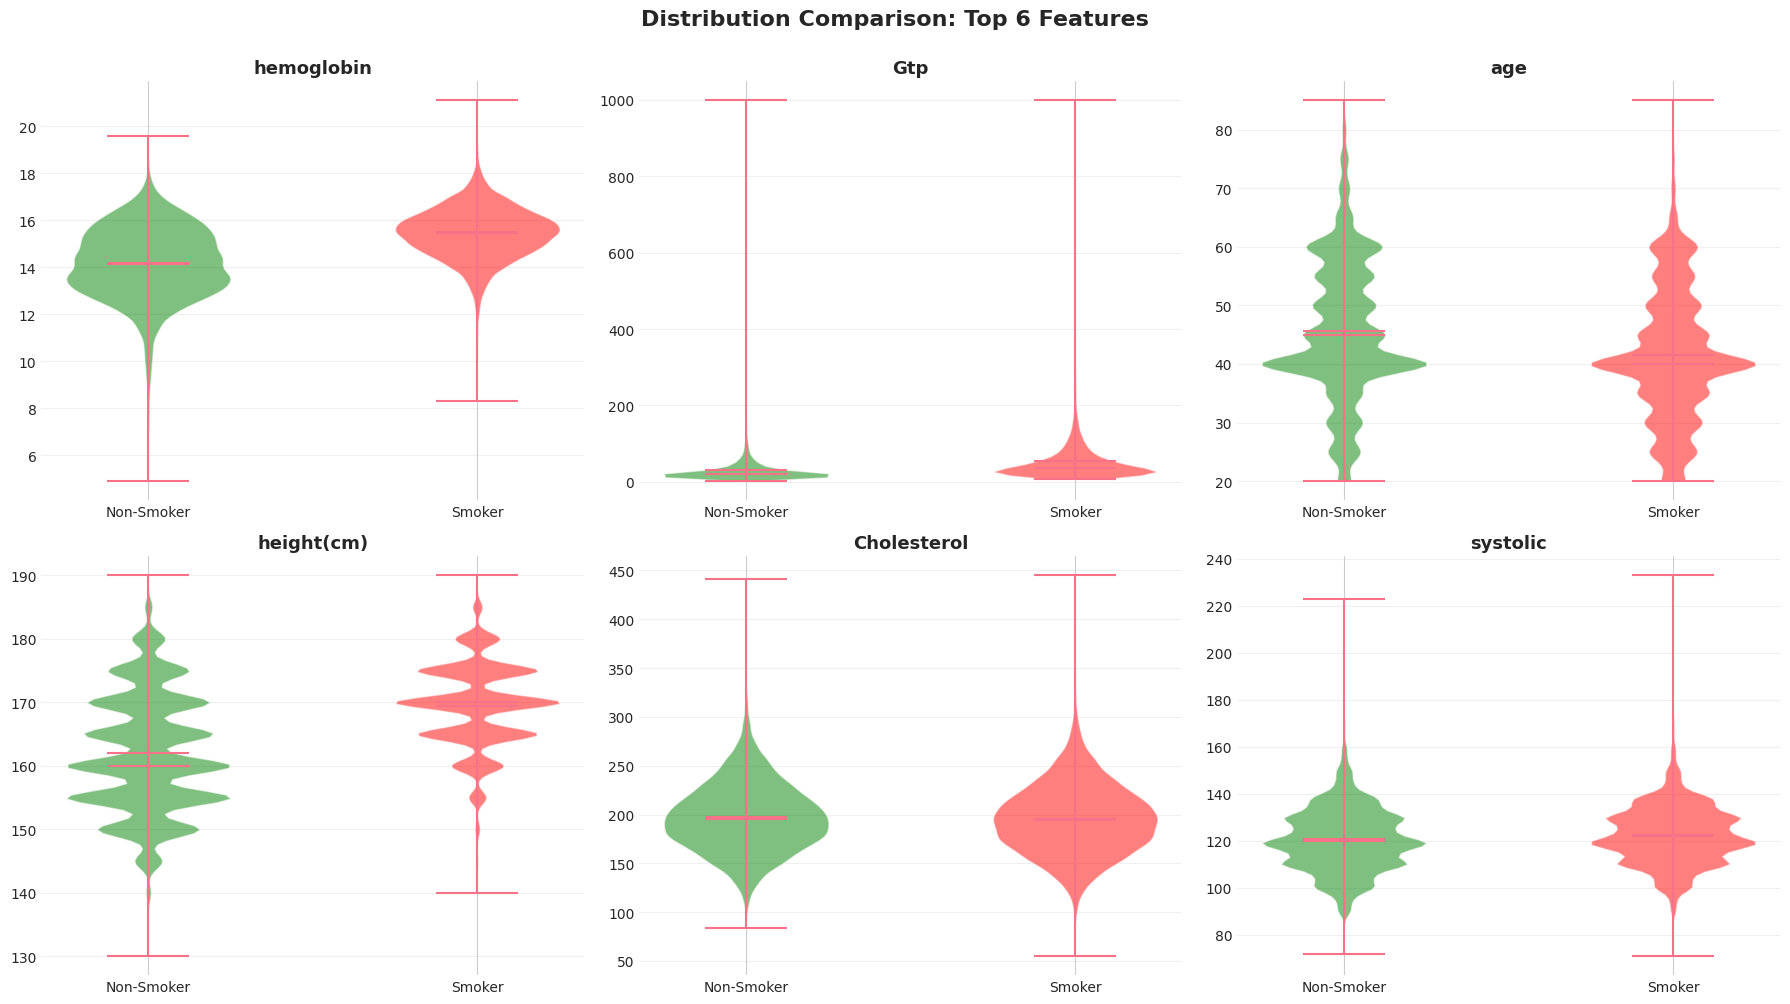

In [90]:
print("="*80)
print("EXPLORATORY DATA ANALYSIS: SMOKERS VS NON-SMOKERS")
print("="*80)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

# Load data
print(f"\nDataset shape: {train_df.shape}")
print(f"Smokers: {train_df['smoking'].sum()} ({train_df['smoking'].mean()*100:.1f}%)")
print(f"Non-smokers: {(1-train_df['smoking']).sum()} ({(1-train_df['smoking'].mean())*100:.1f}%)\n")

# Separate smokers and non-smokers
smokers = train_df[train_df['smoking'] == 1]
non_smokers = train_df[train_df['smoking'] == 0]


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['age'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Age Distribution - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["age"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['age'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Age Distribution - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Age (years)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['age'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["age"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("AGE STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['age'].mean():.1f}, Median={non_smokers['age'].median():.1f}")
print(f"  Smokers:     Mean={smokers['age'].mean():.1f}, Median={smokers['age'].median():.1f}\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['height(cm)'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Height Distribution - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Height (cm)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['height(cm)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["height(cm)"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['height(cm)'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Height Distribution - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Height (cm)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['height(cm)'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["height(cm)"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("HEIGHT STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['height(cm)'].mean():.1f} cm")
print(f"  Smokers:     Mean={smokers['height(cm)'].mean():.1f} cm\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['hemoglobin'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Hemoglobin - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hemoglobin (g/dL)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['hemoglobin'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["hemoglobin"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['hemoglobin'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Hemoglobin - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Hemoglobin (g/dL)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['hemoglobin'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["hemoglobin"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("HEMOGLOBIN STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['hemoglobin'].mean():.2f} g/dL")
print(f"  Smokers:     Mean={smokers['hemoglobin'].mean():.2f} g/dL")
print(f"  Difference:  {smokers['hemoglobin'].mean() - non_smokers['hemoglobin'].mean():.2f} g/dL\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers (log scale for better visualization)
axes[0].hist(non_smokers['Gtp'], bins=50, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('GTP (Liver Enzyme) - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('GTP (U/L)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['Gtp'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["Gtp"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)
axes[0].set_xlim(0, 200)  # Focus on main range

# Smokers
axes[1].hist(smokers['Gtp'], bins=50, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('GTP (Liver Enzyme) - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('GTP (U/L)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['Gtp'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["Gtp"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 200)

plt.tight_layout()
plt.show()

print("GTP STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['Gtp'].mean():.1f} U/L")
print(f"  Smokers:     Mean={smokers['Gtp'].mean():.1f} U/L\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['Cholesterol'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Cholesterol - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cholesterol (mg/dL)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['Cholesterol'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["Cholesterol"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['Cholesterol'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Cholesterol - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cholesterol (mg/dL)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['Cholesterol'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["Cholesterol"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("CHOLESTEROL STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['Cholesterol'].mean():.1f} mg/dL")
print(f"  Smokers:     Mean={smokers['Cholesterol'].mean():.1f} mg/dL\n")


fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Systolic - Non-smokers
axes[0, 0].hist(non_smokers['systolic'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Systolic BP - Non-Smokers', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Systolic BP (mmHg)', fontsize=12)
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[0, 0].axvline(non_smokers['systolic'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["systolic"].mean():.1f}')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Systolic - Smokers
axes[0, 1].hist(smokers['systolic'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Systolic BP - Smokers', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Systolic BP (mmHg)', fontsize=12)
axes[0, 1].set_ylabel('Frequency', fontsize=12)
axes[0, 1].axvline(smokers['systolic'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["systolic"].mean():.1f}')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Diastolic - Non-smokers
axes[1, 0].hist(non_smokers['relaxation'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Diastolic BP - Non-Smokers', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Diastolic BP (mmHg)', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].axvline(non_smokers['relaxation'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["relaxation"].mean():.1f}')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Diastolic - Smokers
axes[1, 1].hist(smokers['relaxation'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Diastolic BP - Smokers', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Diastolic BP (mmHg)', fontsize=12)
axes[1, 1].set_ylabel('Frequency', fontsize=12)
axes[1, 1].axvline(smokers['relaxation'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["relaxation"].mean():.1f}')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("BLOOD PRESSURE STATISTICS:")
print(f"  Systolic - Non-smokers: {non_smokers['systolic'].mean():.1f} mmHg")
print(f"  Systolic - Smokers:     {smokers['systolic'].mean():.1f} mmHg")
print(f"  Diastolic - Non-smokers: {non_smokers['relaxation'].mean():.1f} mmHg")
print(f"  Diastolic - Smokers:     {smokers['relaxation'].mean():.1f} mmHg\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['waist(cm)'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Waist Circumference - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Waist (cm)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['waist(cm)'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["waist(cm)"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['waist(cm)'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Waist Circumference - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Waist (cm)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['waist(cm)'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["waist(cm)"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("WAIST STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['waist(cm)'].mean():.1f} cm")
print(f"  Smokers:     Mean={smokers['waist(cm)'].mean():.1f} cm\n")


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Non-smokers
axes[0].hist(non_smokers['fasting blood sugar'], bins=30, color='green', alpha=0.7, edgecolor='black')
axes[0].set_title('Fasting Blood Sugar - Non-Smokers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Fasting Blood Sugar (mg/dL)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].axvline(non_smokers['fasting blood sugar'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {non_smokers["fasting blood sugar"].mean():.1f}')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Smokers
axes[1].hist(smokers['fasting blood sugar'], bins=30, color='red', alpha=0.7, edgecolor='black')
axes[1].set_title('Fasting Blood Sugar - Smokers', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Fasting Blood Sugar (mg/dL)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].axvline(smokers['fasting blood sugar'].mean(), color='blue', linestyle='--', linewidth=2, label=f'Mean: {smokers["fasting blood sugar"].mean():.1f}')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("FASTING BLOOD SUGAR STATISTICS:")
print(f"  Non-smokers: Mean={non_smokers['fasting blood sugar'].mean():.1f} mg/dL")
print(f"  Smokers:     Mean={smokers['fasting blood sugar'].mean():.1f} mg/dL\n")


fig, axes = plt.subplots(2, 3, figsize=(18, 10))

top_features = ['hemoglobin', 'Gtp', 'age', 'height(cm)', 'Cholesterol', 'systolic']

for idx, feature in enumerate(top_features):
    row = idx // 3
    col = idx % 3

    # Create violin plot
    parts = axes[row, col].violinplot([non_smokers[feature].dropna(), smokers[feature].dropna()],
                                       positions=[0, 1],
                                       showmeans=True,
                                       showmedians=True)

    # Color the violins
    colors = ['green', 'red']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.5)

    axes[row, col].set_title(f'{feature}', fontsize=13, fontweight='bold')
    axes[row, col].set_xticks([0, 1])
    axes[row, col].set_xticklabels(['Non-Smoker', 'Smoker'])
    axes[row, col].grid(alpha=0.3, axis='y')

plt.suptitle('Distribution Comparison: Top 6 Features', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()


# Feature Importance summary

Random Forest Feature Importance

            feature  importance
         hemoglobin       0.103
                Gtp       0.101
         height(cm)       0.098
       triglyceride       0.065
                HDL       0.048
                LDL       0.048
        Cholesterol       0.047
fasting blood sugar       0.046
                ALT       0.046
          waist(cm)       0.045
           systolic       0.043
                AST       0.042
         weight(kg)       0.042
   serum creatinine       0.040
         relaxation       0.040
                age       0.038
                BMI       0.038
    eyesight(right)       0.026
     eyesight(left)       0.026
      dental caries       0.009
      Urine protein       0.004
     hearing(right)       0.002
      hearing(left)       0.002


Logistic Regression Coefficients

            feature  coefficient
         weight(kg)       -1.522
         height(cm)        1.483
                BMI        0.956
         hemoglobin        0.6

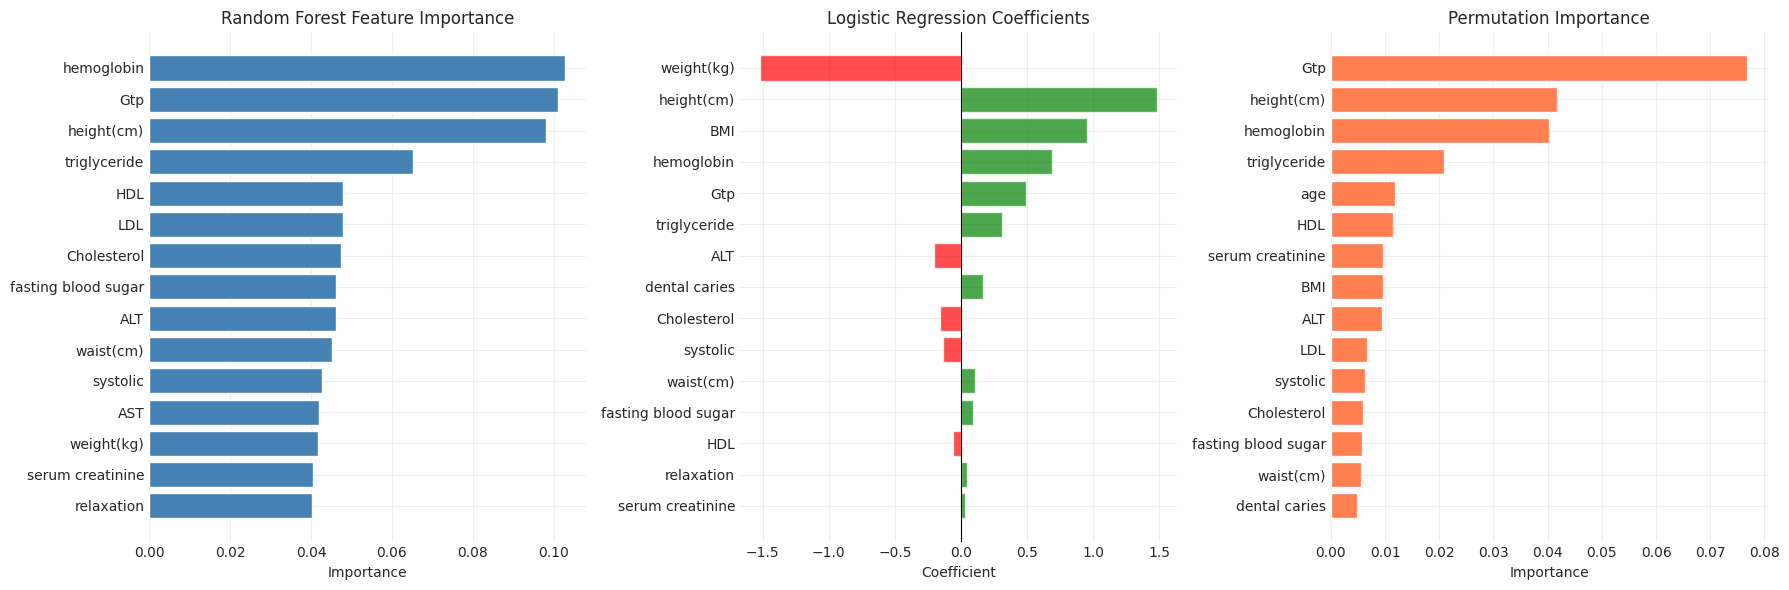


Top 5 Most Important Features (Random Forest):
  hemoglobin: 0.1028
  Gtp: 0.1009
  height(cm): 0.0982
  triglyceride: 0.0651
  HDL: 0.0479


In [99]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X = train_df.drop('smoking', axis=1)
y = train_df['smoking'].values

categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    X = X.drop(columns=categorical_cols)

feature_names = X.columns.tolist()
X = X.values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Random Forest Feature Importance\n")

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(rf_importance.to_string(index=False))

print("\n\nLogistic Regression Coefficients\n")

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_importance = pd.DataFrame({
    'feature': feature_names,
    'coefficient': lr.coef_[0],
    'abs_coefficient': np.abs(lr.coef_[0])
}).sort_values('abs_coefficient', ascending=False)

print(lr_importance[['feature', 'coefficient']].to_string(index=False))

print("\n\nPermutation Importance (Model-Agnostic)\n")

perm_importance = permutation_importance(rf, X_val_scaled, y_val, n_repeats=10, random_state=42, n_jobs=-1)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance': perm_importance.importances_mean
}).sort_values('importance', ascending=False)

print(perm_df.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

top_n = 15

rf_top = rf_importance.head(top_n)
axes[0].barh(range(len(rf_top)), rf_top['importance'], color='steelblue')
axes[0].set_yticks(range(len(rf_top)))
axes[0].set_yticklabels(rf_top['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Random Forest Feature Importance')
axes[0].grid(alpha=0.3)

lr_top = lr_importance.head(top_n)
colors = ['green' if x > 0 else 'red' for x in lr_top['coefficient']]
axes[1].barh(range(len(lr_top)), lr_top['coefficient'], color=colors, alpha=0.7)
axes[1].set_yticks(range(len(lr_top)))
axes[1].set_yticklabels(lr_top['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Coefficient')
axes[1].set_title('Logistic Regression Coefficients')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].grid(alpha=0.3)

perm_top = perm_df.head(top_n)
axes[2].barh(range(len(perm_top)), perm_top['importance'], color='coral')
axes[2].set_yticks(range(len(perm_top)))
axes[2].set_yticklabels(perm_top['feature'])
axes[2].invert_yaxis()
axes[2].set_xlabel('Importance')
axes[2].set_title('Permutation Importance')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nTop 5 Most Important Features (Random Forest):")
for i, row in rf_importance.head(5).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

# Baseline Models

In [100]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}\n")

X = train_df.drop('smoking', axis=1)
y = train_df['smoking'].values

categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"Dropping categorical columns: {list(categorical_cols)}\n")
    X = X.drop(columns=categorical_cols)

X = X.values

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]:,} samples | Validation: {X_val.shape[0]:,} samples")
print(f"Features: {X_train.shape[1]}\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train_scaled, y_train)
lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_val_acc = accuracy_score(y_val, lr.predict(X_val_scaled))
print(f"Logistic Regression:")
print(f"  Train: {lr_train_acc*100:.2f}% | Val: {lr_val_acc*100:.2f}%")

svm = SVC(kernel='rbf', random_state=42, cache_size=2000)
svm.fit(X_train_scaled, y_train)
svm_train_acc = accuracy_score(y_train, svm.predict(X_train_scaled))
svm_val_acc = accuracy_score(y_val, svm.predict(X_val_scaled))
print(f"SVM:")
print(f"  Train: {svm_train_acc*100:.2f}% | Val: {svm_val_acc*100:.2f}%")

class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        return self.network(x)

X_train_tensor = torch.FloatTensor(X_train_scaled)
y_train_tensor = torch.LongTensor(y_train)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True)

model = NeuralNet(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

print("\nTraining Neural Network...\n")

epochs = 100
best_val_acc = 0
best_model_state = None
patience = 15
patience_counter = 0

for epoch in range(epochs):
    model.train()
    total_loss = 0

    for batch_X, batch_y in train_loader:
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)

    model.eval()
    with torch.no_grad():
        val_outputs = model(torch.FloatTensor(X_val_scaled).to(device))
        _, val_preds = torch.max(val_outputs, 1)
        val_acc = accuracy_score(y_val, val_preds.cpu().numpy())

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        patience_counter = 0
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} | Val Acc: {val_acc*100:.2f}%")

    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}\n")
        break

model.load_state_dict(best_model_state)

model.eval()
with torch.no_grad():
    train_outputs = model(torch.FloatTensor(X_train_scaled).to(device))
    _, train_preds = torch.max(train_outputs, 1)
    nn_train_acc = accuracy_score(y_train, train_preds.cpu().numpy())

    val_outputs = model(torch.FloatTensor(X_val_scaled).to(device))
    _, val_preds = torch.max(val_outputs, 1)
    nn_val_acc = accuracy_score(y_val, val_preds.cpu().numpy())

print(f"Neural Network:")
print(f"  Train: {nn_train_acc*100:.2f}% | Val: {nn_val_acc*100:.2f}%")

print("\nModel Comparison:")
print(f"Logistic Regression: Train {lr_train_acc*100:.2f}% | Val {lr_val_acc*100:.2f}% | Gap {(lr_train_acc-lr_val_acc)*100:.2f}%")
print(f"SVM:                 Train {svm_train_acc*100:.2f}% | Val {svm_val_acc*100:.2f}% | Gap {(svm_train_acc-svm_val_acc)*100:.2f}%")
print(f"Neural Network:      Train {nn_train_acc*100:.2f}% | Val {nn_val_acc*100:.2f}% | Gap {(nn_train_acc-nn_val_acc)*100:.2f}%")


Device: cuda
GPU: Tesla T4

Dropping categorical columns: ['BMI_Category']

Train: 33,136 samples | Validation: 5,848 samples
Features: 23

Logistic Regression:
  Train: 72.58% | Val: 72.06%
SVM:
  Train: 78.05% | Val: 75.29%

Training Neural Network...

Epoch 10/100 - Loss: 0.4696 | Val Acc: 75.63%
Epoch 20/100 - Loss: 0.4585 | Val Acc: 75.97%
Epoch 30/100 - Loss: 0.4489 | Val Acc: 76.39%
Epoch 40/100 - Loss: 0.4421 | Val Acc: 76.35%
Epoch 50/100 - Loss: 0.4356 | Val Acc: 76.28%
Early stopping at epoch 58

Neural Network:
  Train: 81.37% | Val: 76.06%

Model Comparison:
Logistic Regression: Train 72.58% | Val 72.06% | Gap 0.52%
SVM:                 Train 78.05% | Val 75.29% | Gap 2.76%
Neural Network:      Train 81.37% | Val 76.06% | Gap 5.31%


# Optimized Neural Network ( using Optuna )

In [97]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import optuna
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}\n")

X = train_df.drop('smoking', axis=1)
y = train_df['smoking'].values

categorical_cols = X.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    print(f"Dropping categorical columns: {list(categorical_cols)}\n")
    X = X.drop(columns=categorical_cols)

X = X.values

print(f"Dataset: {X.shape[0]:,} samples, {X.shape[1]} features\n")

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
print(f"Train: {len(X_train):,} | Validation: {len(X_val):,}\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden1, hidden2, hidden3, dropout1, dropout2):
        super(NeuralNet, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout1),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout2),
            nn.Linear(hidden2, hidden3),
            nn.BatchNorm1d(hidden3),
            nn.ReLU(),
            nn.Linear(hidden3, 2)
        )

    def forward(self, x):
        return self.network(x)

def train_model(model, train_loader, lr, weight_decay, epochs=100, patience=15):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_val_acc = 0
    best_model_state = None
    patience_counter = 0

    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            val_outputs = model(torch.FloatTensor(X_val_scaled).to(device))
            _, val_preds = torch.max(val_outputs, 1)
            val_acc = accuracy_score(y_val, val_preds.cpu().numpy())

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    model.load_state_dict(best_model_state)
    return best_val_acc

def objective(trial):
    hidden1 = trial.suggest_categorical('hidden1', [192, 256, 320, 384])
    hidden2 = trial.suggest_categorical('hidden2', [96, 128, 160, 192])
    hidden3 = trial.suggest_categorical('hidden3', [48, 64, 80, 96])
    dropout1 = trial.suggest_float('dropout1', 0.2, 0.5)
    dropout2 = trial.suggest_float('dropout2', 0.1, 0.4)
    lr = trial.suggest_float('lr', 1e-4, 5e-3, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-6, 1e-4, log=True)
    batch_size = trial.suggest_categorical('batch_size', [256, 512, 1024])

    model = NeuralNet(X.shape[1], hidden1, hidden2, hidden3, dropout1, dropout2).to(device)

    train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_acc = train_model(model, train_loader, lr, weight_decay, epochs=100, patience=15)
    return val_acc

print("Running 30 trials...\n")
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=30, show_progress_bar=True)

print(f"\nBest Validation Accuracy: {study.best_value*100:.2f}%")
print(f"\nBest Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_params = study.best_params

print(f"\nArchitecture: {X.shape[1]} -> {best_params['hidden1']} -> {best_params['hidden2']} -> {best_params['hidden3']} -> 2")
print(f"Dropout: {best_params['dropout1']:.3f}, {best_params['dropout2']:.3f}")
print(f"LR: {best_params['lr']:.6f} | Weight Decay: {best_params['weight_decay']:.6f}")
print(f"Batch Size: {best_params['batch_size']}")

SEEDS = [42, 123, 456, 789, 2024]
print(f"\nTrying {len(SEEDS)} different random seeds...\n")

best_model = None
best_seed_acc = 0
best_seed = None

for seed in SEEDS:
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = NeuralNet(
        X.shape[1],
        best_params['hidden1'],
        best_params['hidden2'],
        best_params['hidden3'],
        best_params['dropout1'],
        best_params['dropout2']
    ).to(device)

    train_dataset = TensorDataset(torch.FloatTensor(X_train_scaled), torch.LongTensor(y_train))
    train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)

    val_acc = train_model(model, train_loader, best_params['lr'], best_params['weight_decay'], epochs=150, patience=20)

    print(f"  Seed {seed:4d}: {val_acc*100:.2f}%")

    if val_acc > best_seed_acc:
        best_seed_acc = val_acc
        best_model = model
        best_seed = seed

print(f"\nBest: Seed {best_seed} with {best_seed_acc*100:.2f}% accuracy")

[I 2025-12-12 16:19:02,279] A new study created in memory with name: no-name-ad3827ca-8089-42cc-8c35-a4a22e079f34



Device: cuda
GPU: Tesla T4

Dropping categorical columns: ['BMI_Category']

Dataset: 38,984 samples, 23 features

Train: 33,136 | Validation: 5,848

Running 30 trials...



  0%|          | 0/30 [00:00<?, ?it/s]

[I 2025-12-12 16:19:48,135] Trial 0 finished with value: 0.7659028727770177 and parameters: {'hidden1': 256, 'hidden2': 192, 'hidden3': 96, 'dropout1': 0.4497327922401265, 'dropout2': 0.16370173320348286, 'lr': 0.00020366442026830908, 'weight_decay': 2.3270677083837795e-06, 'batch_size': 512}. Best is trial 0 with value: 0.7659028727770177.
[I 2025-12-12 16:20:10,904] Trial 1 finished with value: 0.7648768809849521 and parameters: {'hidden1': 256, 'hidden2': 160, 'hidden3': 96, 'dropout1': 0.2511572371061875, 'dropout2': 0.11951547789558387, 'lr': 0.004093813608598782, 'weight_decay': 8.536189862866841e-05, 'batch_size': 256}. Best is trial 0 with value: 0.7659028727770177.
[I 2025-12-12 16:20:30,540] Trial 2 finished with value: 0.7647058823529411 and parameters: {'hidden1': 192, 'hidden2': 128, 'hidden3': 80, 'dropout1': 0.49087538832936756, 'dropout2': 0.3325398470083344, 'lr': 0.003946212980759096, 'weight_decay': 6.161049539380962e-05, 'batch_size': 512}. Best is trial 0 with valu